# 07 — Results, Figures and Statistics

Reads the encoding output written by notebook 06 and produces the figures and
statistical tests for the report.

## What changed from the previous version

- **Folders are `RUN_TAG`-aware.** Notebook 06 versions its output so a new run
  can never silently reuse files from an older, incompatible pipeline.
- **Electrode selection is no longer applied here.** Notebook 06 restricts `raw`
  to the pre-specified language-responsive electrodes *before* encoding, so every
  row of every saved array is already a selected electrode. Re-indexing here
  would double-select.
- **`noise_*` conditions are gone.** Significance now comes from the exact
  circular-shift permutation test (`null subj=... .npz`).
- **Unbiased summary statistic.** `win_r` = mean r over a pre-specified
  0–0.5 s post-onset window. Per-electrode maxima are never averaged: the maximum
  of many correlated estimates is positively biased even under the null
  (~0.07 with 256 lags), which previously compressed all conditions together.
- **Residual conditions are tested against their shift control**, not against
  English alone. English-alone comparisons are confounded by design width.

## Statistical tests

For each residual condition, three paired t-tests across subjects (FDR-corrected):

| Contrast | Question |
|---|---|
| residual vs English | what the original analysis measured (width-confounded) |
| residual vs shift control | **does the residual carry neural information?** |
| English vs shift control | the capacity cost of a wider design |


## 1. Imports

In [1]:
import os
import re
import json
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

try:
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not found — p-values will be uncorrected.')

warnings.filterwarnings('ignore')
print('Imports ready.')

Imports ready.


## 2. Configuration

In [2]:
RESULTS_DIR = '../results/'
RUN_TAG     = 'final_sm200'        # must match notebook 06
freq        = 64
tmin, tmax  = -2.0, 2.0

# Pre-specified analysis window (post word onset). Chosen a priori, not tuned.
WINDOW     = (0.0, 0.5)
PRE_RANGE  = (-0.8, 0.0)
POST_RANGE = (0.0,  0.8)

FDR_Q = 0.01                       # Goldstein et al. 2022 threshold

# Display-only smoothing of the plotted curves. The neural signal is already
# averaged over a 200 ms window in notebook 06, so this is normally 0.
# Raise to ~1.5 only if the curves still look ragged.
DISPLAY_SIGMA_MS = 45.0
DISPLAY_SIGMA    = DISPLAY_SIGMA_MS / (1000.0 / freq)   # -> samples

MODES  = ['fasttext', 'contextual', 'sliding_window', 'xglm', 'gemmax2']
SUFFIX = {'fasttext': 'ft', 'contextual': 'ctx', 'sliding_window': 'sw',
          'xglm': 'xglm', 'gemmax2': 'gemmax2'}

# Display order: static baseline first, then bidirectional, then causal
MODE_ORDER = ['fasttext', 'sliding_window', 'contextual', 'xglm', 'gemmax2']


def out_folder(mode):
    return os.path.join(RESULTS_DIR,
                        f'encoding_{mode}_{RUN_TAG}_{freq}Hz_({tmin},{tmax})')


def cond_name(mode, key):
    s = SUFFIX[mode]
    return {'en': f'en_{s}', 'he': f'he_{s}', 'ar': f'ar_{s}',
            'en_he_res':   f'en+he_{s}_res',
            'en_ar_res':   f'en+ar_{s}_res',
            'en_he_shift': f'en+he_{s}_res_shift',
            'en_ar_shift': f'en+ar_{s}_res_shift'}[key]


AVAILABLE_MODES = [m for m in MODE_ORDER if os.path.isdir(out_folder(m))]

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#333333',
    'axes.labelsize'    : 12.5,
    'axes.labelcolor'   : '#222222',
    'axes.titlesize'    : 14.5,
    'axes.titleweight'  : 'medium',
    'axes.titlepad'     : 10,
    'axes.axisbelow'    : True,
    'xtick.labelsize'   : 11,
    'ytick.labelsize'   : 11,
    'xtick.color'       : '#444444',
    'ytick.color'       : '#444444',
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'xtick.major.size'  : 4,
    'ytick.major.size'  : 4,
    'legend.fontsize'   : 10.5,
    'legend.frameon'    : False,
    'legend.handlelength': 1.5,
    'legend.labelspacing': 0.45,
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size'         : 12,
    'text.color'        : '#222222',
    'lines.linewidth'   : 2.2,
    'lines.solid_capstyle': 'round',
    'figure.dpi'        : 130,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
    'pdf.fonttype'      : 42,
})

# ── Colour system (Okabe-Ito derived, colourblind-safe) ──────────────────────
LANG_COL = {'en': '#1F77B4', 'he': '#E8710A', 'ar': '#12A594'}
LANG_LAB = {'en': 'English', 'he': 'Hebrew', 'ar': 'Arabic'}

MODE_COL = {
    'fasttext'      : '#9AA0A6',   # grey   — static
    'sliding_window': '#C2306B',   # magenta — bidirectional, window
    'contextual'    : '#1F77B4',   # blue   — bidirectional, sentence
    'xglm'          : '#E8710A',   # amber  — causal
    'gemmax2'       : '#12A594',   # teal   — causal
}
MODE_LABEL = {
    'fasttext'      : 'FastText (static)',
    'sliding_window': 'XLM-R (content words ctx)',
    'contextual'    : 'XLM-R (sentence ctx)',
    'xglm'          : 'XGLM-1.7B (causal)',
    'gemmax2'       : 'GemmaX2-28-2B (causal)',
}
MODE_SHORT = {
    'fasttext'      : 'FastText\n(static)',
    'sliding_window': 'XLM-R\n(content words)',
    'contextual'    : 'XLM-R\n(sentence)',
    'xglm'          : 'XGLM\n(causal)',
    'gemmax2'       : 'GemmaX2\n(causal)',
}

RES_COL = {'real': '#C2306B', 'shift': '#B0B4B8', 'en': '#1F77B4'}

SEM_ALPHA  = 0.16
PANEL_TINT = 0.035
FIG_DIR = os.path.join(RESULTS_DIR, f'figures_{RUN_TAG}')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'Run tag         : {RUN_TAG}')
print(f'Available modes : {AVAILABLE_MODES}')
print(f'Window          : {WINDOW[0]}-{WINDOW[1]} s post onset')
print(f'Figures         : {os.path.abspath(FIG_DIR)}')

Run tag         : final_sm200
Available modes : ['fasttext', 'sliding_window', 'contextual', 'xglm', 'gemmax2']
Window          : 0.0-0.5 s post onset
Figures         : /Users/YAHLIZ/Desktop/Language-Project-main/results/figures_final_sm200


## 3. Loaders and Helpers

Every saved array already contains only the pre-specified electrodes, in `raw`
channel order. `channels subj=XX.npy` gives their names for labelling — it is not
used for indexing.

In [3]:
from matplotlib.colors import to_rgba
from scipy.ndimage import gaussian_filter1d

# Discover subjects from whichever mode has files
subjects = set()
for m in AVAILABLE_MODES:
    for fp in glob.glob(os.path.join(out_folder(m), 'corrs subj=* - *.npy')):
        mt = re.search(r'corrs subj=(\w+) -', os.path.basename(fp))
        if mt:
            subjects.add(mt.group(1))
subjects = sorted(subjects)

channels = {}
for m in AVAILABLE_MODES:
    for subj in subjects:
        fp = os.path.join(out_folder(m), f'channels subj={subj}.npy')
        if subj not in channels and os.path.exists(fp):
            channels[subj] = np.load(fp, allow_pickle=True)

print(f'Subjects : {subjects}')
for s in subjects:
    print(f'  sub-{s}: {len(channels.get(s, []))} electrodes')
print(f'Total    : {sum(len(v) for v in channels.values())} electrodes')

_LAGS = {}
def lags_for(n_times):
    if n_times not in _LAGS:
        _LAGS[n_times] = np.linspace(tmin, tmax, n_times)
    return _LAGS[n_times]


def load_cv(mode, key, subj):
    # Fold-averaged correlations, (n_electrodes, n_times), or None.
    # Every row is already a pre-specified electrode: notebook 06 restricts
    # raw before encoding, so no re-indexing happens here.
    fp = os.path.join(out_folder(mode), f'corrs subj={subj} - {cond_name(mode, key)}.npy')
    return np.load(fp).mean(0) if os.path.exists(fp) else None


def curve(mode, key, subj, smooth=True):
    # Electrode-averaged lag curve. Electrodes are averaged BEFORE any max.
    cv = load_cv(mode, key, subj)
    if cv is None:
        return None
    c = cv.mean(0)
    if smooth and DISPLAY_SIGMA > 0:
        c = gaussian_filter1d(c, DISPLAY_SIGMA)
    return c


def win_r(mode, key, subj):
    # Primary statistic: mean r in the pre-specified post-onset window.
    c = curve(mode, key, subj, smooth=False)
    if c is None:
        return None
    lg = lags_for(len(c))
    return float(c[(lg >= WINDOW[0]) & (lg <= WINDOW[1])].mean())


def range_mean(mode, key, rng):
    out = {}
    for s in subjects:
        c = curve(mode, key, s, smooth=False)
        if c is None:
            continue
        lg = lags_for(len(c))
        out[s] = float(c[(lg >= rng[0]) & (lg <= rng[1])].mean())
    return out


def per_subject(mode, key, fn=win_r):
    return {s: v for s in subjects for v in [fn(mode, key, s)] if v is not None}


def grand_avg(mode, key):
    cs = [curve(mode, key, s) for s in subjects]
    cs = [c for c in cs if c is not None]
    if not cs:
        return None, None, None, 0
    n = min(len(c) for c in cs)
    arr = np.stack([c[:n] for c in cs])
    return lags_for(n), arr.mean(0), arr.std(0, ddof=1) / np.sqrt(len(arr)), len(arr)


def frac_significant(mode, key):
    out = {}
    for subj in subjects:
        fp = os.path.join(out_folder(mode), f'null subj={subj} - {cond_name(mode, key)}.npz')
        if not os.path.exists(fp):
            continue
        z = np.load(fp)
        k = 'p_electrode' if 'p_electrode' in z.files else 'p'
        p = np.asarray(z[k]).ravel()
        if HAS_STATSMODELS:
            rej, _, _, _ = multipletests(p, alpha=FDR_Q, method='fdr_bh')
        else:
            rej = p < FDR_Q
        out[subj] = float(np.mean(rej))
    return out


def paired_test(a, b):
    shared = sorted(set(a) & set(b))
    if len(shared) < 2:
        return np.nan, np.nan, np.nan, np.nan, len(shared)
    x = np.array([a[s] for s in shared]); y = np.array([b[s] for s in shared])
    d = x - y
    t, p = stats.ttest_rel(x, y)
    return float(d.mean()), float(t), float(p), float(d.mean()/(d.std(ddof=1)+1e-12)), len(shared)


def fdr(pvals):
    arr = np.asarray(pvals, dtype=float)
    ok = ~np.isnan(arr)
    out = np.full_like(arr, np.nan)
    if HAS_STATSMODELS and ok.sum():
        _, corr, _, _ = multipletests(arr[ok], method='fdr_bh')
        out[ok] = corr
    else:
        out[ok] = arr[ok]
    return out


def stars(p):
    if np.isnan(p): return ''
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'


# ── Presentation helpers ─────────────────────────────────────────────────────

def panel_chip(ax, text, color, x=0.025, y=0.965, fs=10.5):
    # Rounded colour-coded badge naming the panel, top-left inside the axes.
    ax.text(x, y, text, transform=ax.transAxes, fontsize=fs, fontweight='medium',
            color=color, va='top', ha='left', zorder=6,
            bbox=dict(boxstyle='round,pad=0.42', fc=to_rgba(color, 0.12),
                      ec='none'))


def tint(ax, color, alpha=PANEL_TINT):
    ax.set_facecolor(to_rgba(color, alpha))


def onset_line(ax, label=True, label_y=0.97):
    ax.axvline(0, color='#555555', lw=1.0, ls=(0, (4, 3)), alpha=0.8, zorder=2)
    if label:
        ax.text(0.02, label_y, 'word onset', transform=ax.get_xaxis_transform(),
                fontsize=8.6, color='#777777', ha='left', va='top', zorder=6)


def decorate(ax, ylabel='Pearson r', xlabel='Time lag (s)', onset=True,
             onset_label=True, window=True):
    if window:
        ax.axvspan(*WINDOW, color='#000000', alpha=0.045, lw=0, zorder=0)
    if onset:
        onset_line(ax, label=onset_label)
    ax.axhline(0, color='#C8C8C8', lw=0.8, zorder=1)
    ax.grid(axis='y', color='#EEEEEE', lw=0.7, zorder=0)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_xlim(tmin, tmax)
    ax.xaxis.set_minor_locator(MultipleLocator(0.5))


def bar_with_points(ax, xpos, values, color, width=0.62, jitter=0.085,
                    show_points=True):
    # Soft bar to the mean, heavy mean rule, dark SEM whisker, jittered subjects.
    v = np.asarray(values, dtype=float)
    if v.size == 0:
        return np.nan
    m  = v.mean()
    se = v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
    ax.bar(xpos, m, width=width, color=to_rgba(color, 0.20), edgecolor='none',
           zorder=2)
    ax.plot([xpos - width/2, xpos + width/2], [m, m], color=color, lw=3.4,
            solid_capstyle='butt', zorder=4)
    if se > 0:
        ax.errorbar(xpos, m, yerr=se, color='#333333', lw=1.6, capsize=0, zorder=5)
    if show_points:
        rng = np.random.RandomState(0)
        ax.scatter(xpos + rng.uniform(-jitter, jitter, len(v)), v, s=26,
                   color=color, alpha=0.75, linewidths=0.6, edgecolors='white',
                   zorder=6)
    return m


def footnote(fig, text, y=-0.015, fontsize=14):
    fig.text(0.5, y, text, ha='center', va='top', fontsize=fontsize, color='#777777')


def suptitle(fig, text, y=1.03, fs=15):
    fig.suptitle(text, y=y, fontsize=fs, fontweight='semibold', color='#111111')


def save_fig(fig, name):
    p = os.path.join(FIG_DIR, name)
    fig.savefig(p); fig.savefig(p.replace('.png', '.pdf'))
    print(f'  saved -> {p}')
    plt.show()

print('\nHelpers ready.')

Subjects : ['03', '04', '05', '06', '07', '08', '09']
  sub-03: 38 electrodes
  sub-04: 14 electrodes
  sub-05: 8 electrodes
  sub-06: 40 electrodes
  sub-07: 12 electrodes
  sub-08: 16 electrodes
  sub-09: 31 electrodes
Total    : 159 electrodes

Helpers ready.


## Figure 1 — Language comparison per model

English, Hebrew and Arabic embeddings predicting the same English-listening
brains. English should lead in every panel; it is the basic sanity check.

  saved -> ../results/figures_final_sm200/fig1_language_by_mode.png


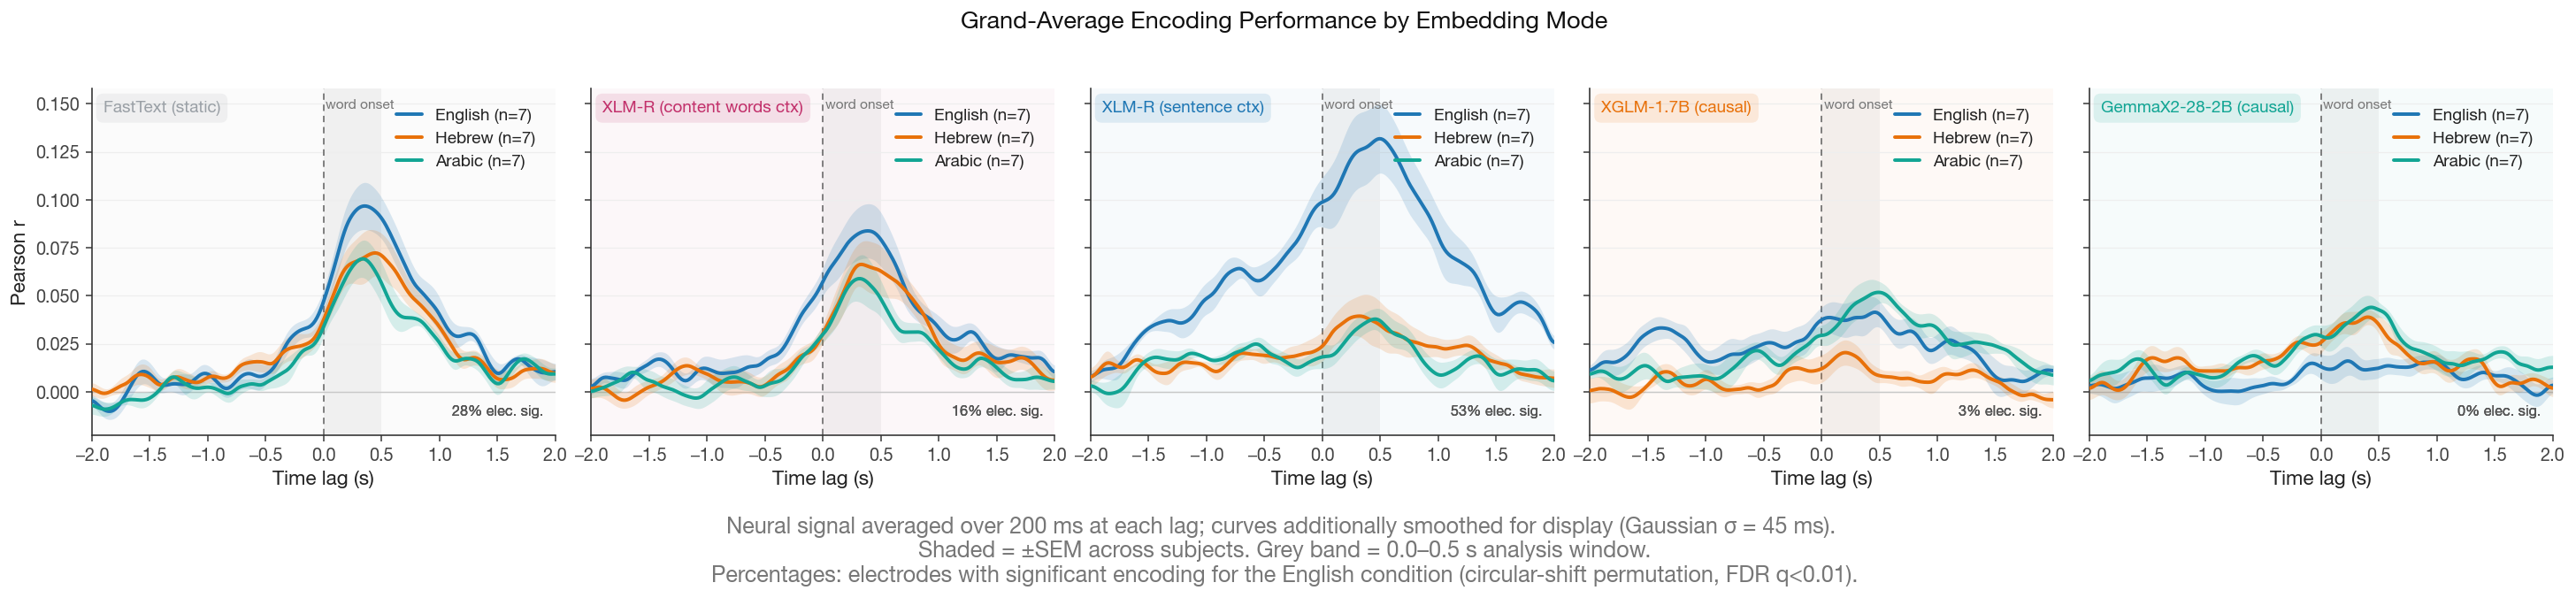

In [20]:
n = len(AVAILABLE_MODES)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, mode in zip(axes, AVAILABLE_MODES):
    tint(ax, MODE_COL[mode])
    for lang in ['en', 'he', 'ar']:
        lg, m, se, k = grand_avg(mode, lang)
        if m is None:
            continue
        ax.plot(lg, m, color=LANG_COL[lang], label=f'{LANG_LAB[lang]} (n={k})',
                zorder=5)
        ax.fill_between(lg, m - se, m + se, color=LANG_COL[lang],
                        alpha=SEM_ALPHA, lw=0, zorder=3)
        # Figure 1, inside the mode loop, after plotting:
        fs = frac_significant(mode, 'en')
        if fs:
            ax.text(0.975, 0.05, f"{100*np.mean(list(fs.values())):.0f}% elec. sig.",
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=9, color='#555555')
    decorate(ax, ylabel='Pearson r' if ax is axes[0] else '')
    panel_chip(ax, MODE_LABEL[mode], MODE_COL[mode])
    ax.legend(loc='upper right', borderaxespad=0.8)

suptitle(fig, 'Grand-Average Encoding Performance by Embedding Mode')
footnote(fig, (f'Neural signal averaged over 200 ms at each lag; curves additionally '
              f'smoothed for display (Gaussian \u03c3 = {DISPLAY_SIGMA_MS:.0f} ms). \n'
              f'Shaded = \u00b1SEM across subjects.'
              f' Grey band = {WINDOW[0]}\u2013{WINDOW[1]} s analysis window.\n'
              f'Percentages: electrodes with significant encoding for the English condition (circular-shift permutation, FDR q<0.01).'))

fig.tight_layout()
save_fig(fig, 'fig1_language_by_mode.png')

## Figure 2 — Model comparison (English only)

The contextual-versus-static question. All models here are evaluated on the same
electrodes with the same null.

  saved -> ../results/figures_final_sm200/fig2_model_comparison_english.png


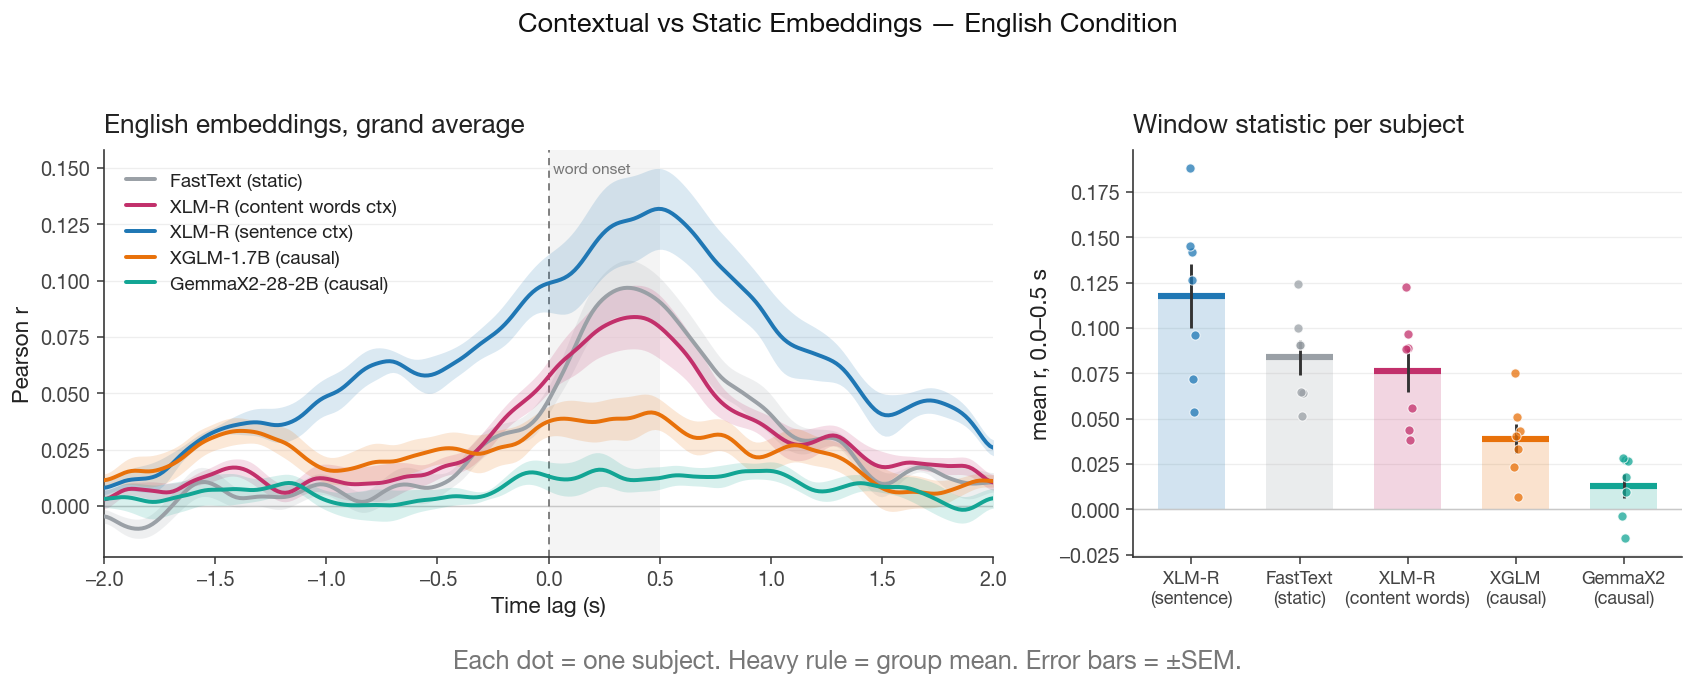

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 4.6),
                               gridspec_kw={'width_ratios': [1.62, 1]})

for mode in AVAILABLE_MODES:
    lg, m, se, k = grand_avg(mode, 'en')
    if m is None:
        continue
    ax1.plot(lg, m, color=MODE_COL[mode], label=MODE_LABEL[mode], zorder=5)
    ax1.fill_between(lg, m - se, m + se, color=MODE_COL[mode],
                     alpha=SEM_ALPHA, lw=0, zorder=3)
decorate(ax1)
ax1.set_title('English embeddings, grand average', loc='left')
ax1.legend(loc='upper left', borderaxespad=0.8)

vals  = {m: per_subject(m, 'en') for m in AVAILABLE_MODES}
order = sorted([m for m in AVAILABLE_MODES if vals[m]],
               key=lambda m: -np.mean(list(vals[m].values())))
for i, m in enumerate(order):
    bar_with_points(ax2, i, list(vals[m].values()), MODE_COL[m])
ax2.set_xticks(range(len(order)))
ax2.set_xticklabels([MODE_SHORT[m] for m in order], fontsize=10)
ax2.axhline(0, color='#C8C8C8', lw=0.8)
ax2.grid(axis='y', color='#EEEEEE', lw=0.7)
ax2.set_ylabel(f'mean r, {WINDOW[0]}\u2013{WINDOW[1]} s')
ax2.set_title('Window statistic per subject', loc='left')

suptitle(fig, 'Contextual vs Static Embeddings \u2014 English Condition', y=1.05)
footnote(fig, 'Each dot = one subject. Heavy rule = group mean. Error bars = \u00b1SEM.')
fig.tight_layout()
save_fig(fig, 'fig2_model_comparison_english.png')

## Figure 3 — Residual vs its dimensionality-matched control

**The central result.** If the cross-lingual residual carried neural information,
the red curve would sit above the grey one. English alone is shown for reference;
note that both two-block conditions fall below it by a similar amount, which is
the capacity cost of a wider design rather than an effect of the residual.

  saved -> ../results/figures_final_sm200/fig3_residual_vs_shift.png


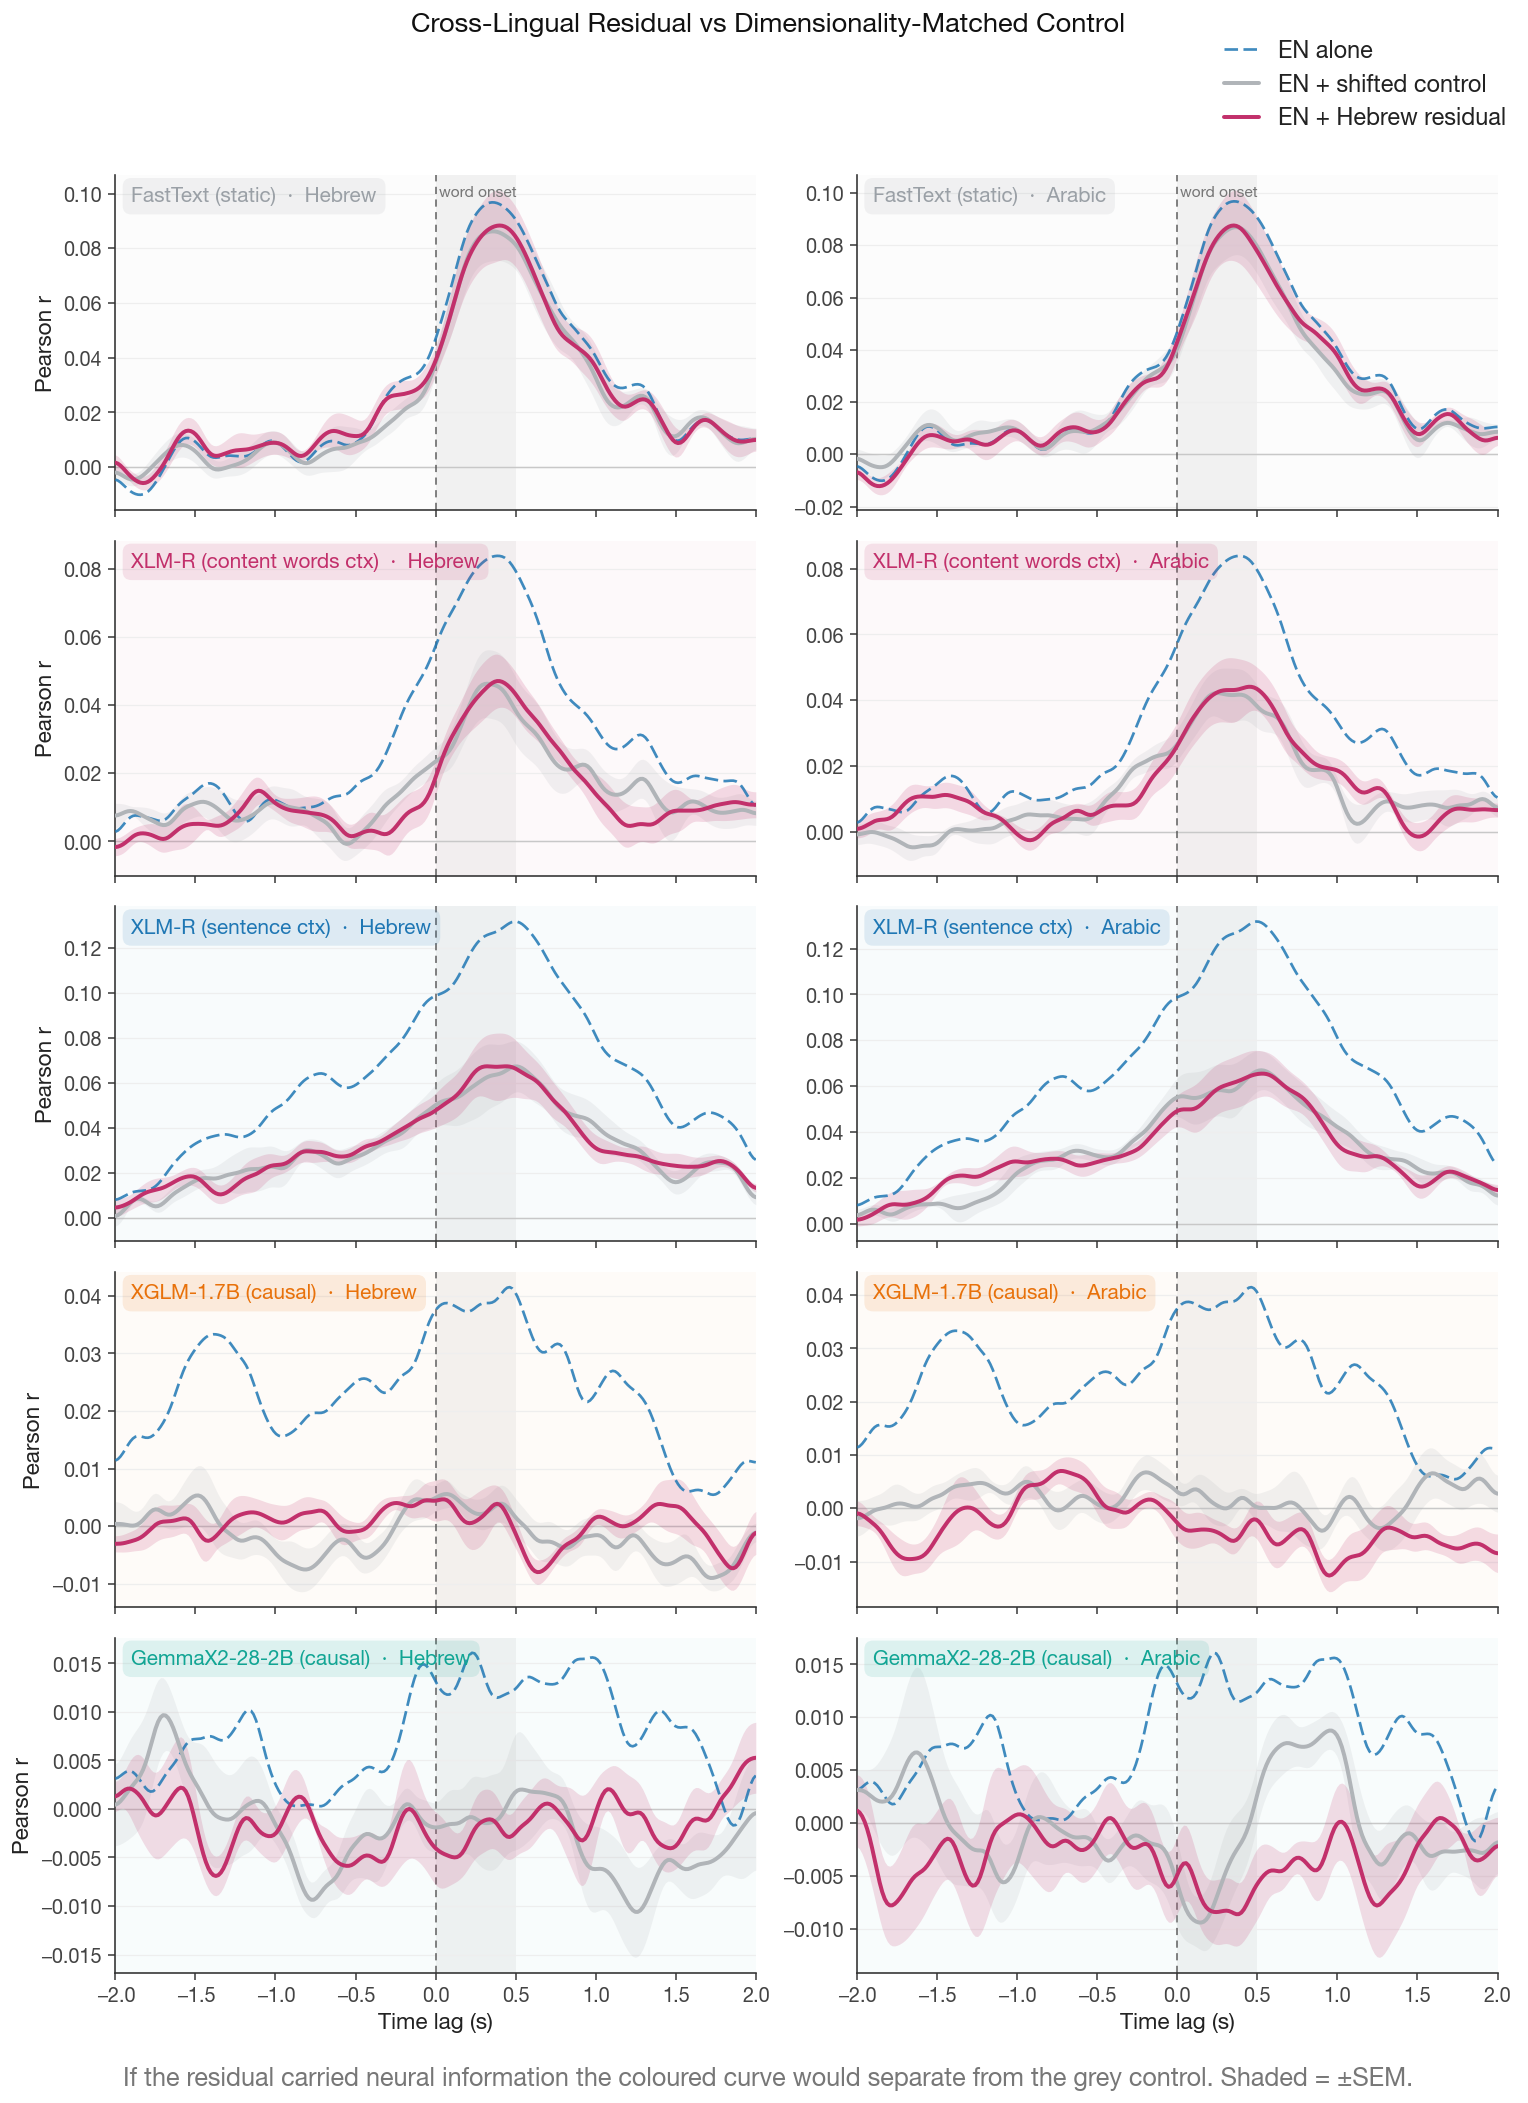

In [6]:
rows = len(AVAILABLE_MODES)
fig, axes = plt.subplots(rows, 2, figsize=(11.8, 3.15 * rows), sharex=True)
axes = np.atleast_2d(axes)

for r, mode in enumerate(AVAILABLE_MODES):
    for c, (rk, sk, lang) in enumerate([('en_he_res', 'en_he_shift', 'Hebrew'),
                                        ('en_ar_res', 'en_ar_shift', 'Arabic')]):
        ax = axes[r, c]
        tint(ax, MODE_COL[mode], alpha=0.028)

        lg, m_en, se_en, _ = grand_avg(mode, 'en')
        if m_en is not None:
            ax.plot(lg, m_en, color=RES_COL['en'], lw=1.5, ls=(0, (5, 2)),
                    alpha=0.85, label='EN alone', zorder=4)
        for key, col, lab in [(sk, RES_COL['shift'], 'EN + shifted control'),
                              (rk, RES_COL['real'],  f'EN + {lang} residual')]:
            lg, m, se, k = grand_avg(mode, key)
            if m is None:
                continue
            ax.plot(lg, m, color=col, label=lab, zorder=5)
            ax.fill_between(lg, m - se, m + se, color=col, alpha=SEM_ALPHA,
                            lw=0, zorder=3)

        decorate(ax, ylabel='Pearson r' if c == 0 else '',
                 xlabel='Time lag (s)' if r == rows - 1 else '',
                 onset_label=(r == 0))
        panel_chip(ax, f'{MODE_LABEL[mode]}  ·  {lang}', MODE_COL[mode], fs=11.5)

fig.tight_layout(rect=[0, 0, 1, 0.93])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.995, 0.995),
          fontsize=13, frameon=False, borderaxespad=0.5)

suptitle(fig, 'Cross-Lingual Residual vs Dimensionality-Matched Control', y=0.998)
footnote(fig, 'If the residual carried neural information the coloured curve would '
              'separate from the grey control. Shaded = ±SEM.', y=-0.005)
save_fig(fig, 'fig3_residual_vs_shift.png')

## Figure 4 — What the control absorbs

The methodological result in one panel. The left bar of each pair is the contrast
the original analysis made (residual vs English alone); the right bar is the same
residual against a width-matched control. The difference between them is design
capacity, not cross-lingual information.

  saved -> ../results/figures_final_sm200/fig4_delta_decomposition.png


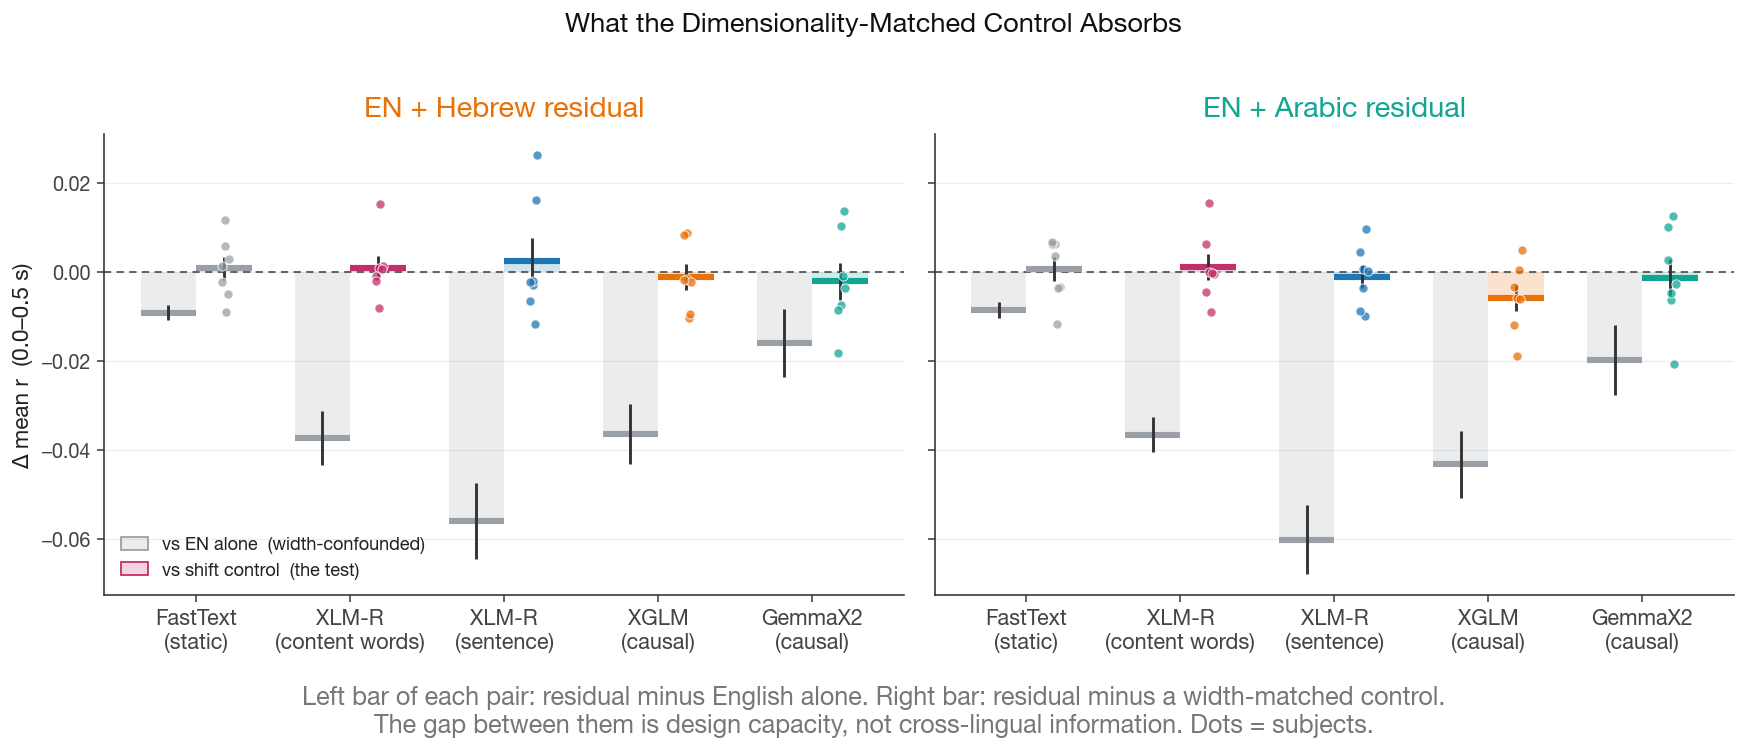

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0), sharey=True)

for ax, (rk, sk, lang, lcol) in zip(axes, [
        ('en_he_res', 'en_he_shift', 'Hebrew', LANG_COL['he']),
        ('en_ar_res', 'en_ar_shift', 'Arabic', LANG_COL['ar'])]):

    modes_here, w = [], 0.36
    for mode in AVAILABLE_MODES:
        a = per_subject(mode, rk); b = per_subject(mode, 'en'); c = per_subject(mode, sk)
        if not a or not b or not c:
            continue
        shared = sorted(set(a) & set(b) & set(c))
        i = len(modes_here)
        d_en = [a[s] - b[s] for s in shared]
        d_sh = [a[s] - c[s] for s in shared]
        bar_with_points(ax, i - w/2, d_en, '#9AA0A6', width=w, show_points=False)
        bar_with_points(ax, i + w/2, d_sh, MODE_COL[mode], width=w)
        modes_here.append(mode)

    ax.axhline(0, color='#555555', lw=1.0, ls=(0, (4, 3)))
    ax.grid(axis='y', color='#EEEEEE', lw=0.7)
    ax.set_xticks(range(len(modes_here)))
    ax.set_xticklabels([MODE_SHORT[m] for m in modes_here], fontsize=12)
    ax.set_title(f'EN + {lang} residual', loc='center', fontsize=16,
                 color=lcol, fontweight='semibold')
    if ax is axes[0]:
        ax.set_ylabel(f'\u0394 mean r  ({WINDOW[0]}\u2013{WINDOW[1]} s)')

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor=to_rgba('#9AA0A6', 0.20), edgecolor='#9AA0A6',
          label='vs EN alone  (width-confounded)'),
    Patch(facecolor=to_rgba('#C2306B', 0.20), edgecolor='#C2306B',
          label='vs shift control  (the test)')],
    loc='lower left', fontsize=10)

suptitle(fig, 'What the Dimensionality-Matched Control Absorbs', y=1.02)
footnote(fig, 'Left bar of each pair: residual minus English alone. Right bar: residual '
              'minus a width-matched control.\nThe gap between them is design capacity, '
              'not cross-lingual information. Dots = subjects.')
fig.tight_layout()
save_fig(fig, 'fig4_delta_decomposition.png')

## Figure 5 — Pre- versus post-onset

Bidirectional models can attend to words after the target within their context
window, so pre-onset encoding may partly reflect that rather than neural
prediction. Reported descriptively.

  saved -> ../results/figures_final_sm200/fig5_pre_post_onset.png


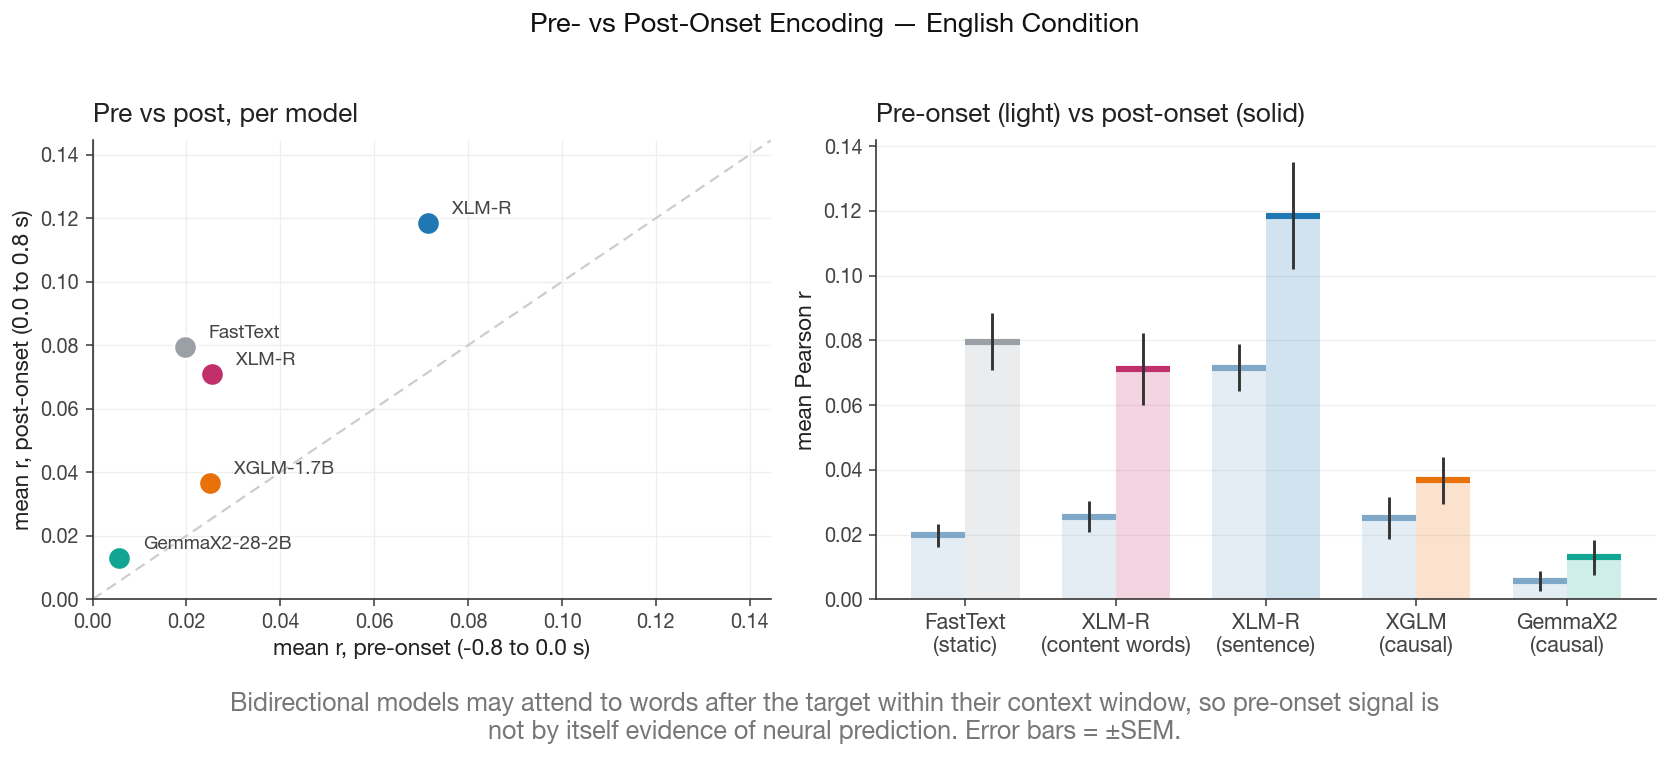

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.0, 5.0),
                               gridspec_kw={'width_ratios': [1, 1.15]})

pre  = {m: np.mean(list(range_mean(m, 'en', PRE_RANGE).values()))  for m in AVAILABLE_MODES}
post = {m: np.mean(list(range_mean(m, 'en', POST_RANGE).values())) for m in AVAILABLE_MODES}

lim = max(max(pre.values()), max(post.values())) * 1.22
ax1.plot([0, lim], [0, lim], color='#CCCCCC', ls=(0, (5, 3)), lw=1.2, zorder=1)
for m in AVAILABLE_MODES:
    ax1.scatter(pre[m], post[m], s=170, color=MODE_COL[m], zorder=4,
                edgecolors='white', linewidths=1.6)
    ax1.annotate(MODE_LABEL[m].split(' (')[0], (pre[m], post[m]),
                 textcoords='offset points', xytext=(13, 5), fontsize=10.5,
                 color='#444444')
ax1.axhline(0, color='#C8C8C8', lw=0.8); ax1.axvline(0, color='#C8C8C8', lw=0.8)
ax1.grid(color='#EEEEEE', lw=0.7)
ax1.set_xlim(0, lim); ax1.set_ylim(0, lim)
ax1.set_xlabel(f'mean r, pre-onset ({PRE_RANGE[0]} to {PRE_RANGE[1]} s)')
ax1.set_ylabel(f'mean r, post-onset ({POST_RANGE[0]} to {POST_RANGE[1]} s)')
ax1.set_title('Pre vs post, per model', loc='left')

w = 0.36
for i, m in enumerate(AVAILABLE_MODES):
    bar_with_points(ax2, i - w/2, list(range_mean(m, 'en', PRE_RANGE).values()),
                    '#7FA8C9', width=w, show_points=False)
    bar_with_points(ax2, i + w/2, list(range_mean(m, 'en', POST_RANGE).values()),
                    MODE_COL[m], width=w, show_points=False)
ax2.axhline(0, color='#C8C8C8', lw=0.8)
ax2.grid(axis='y', color='#EEEEEE', lw=0.7)
ax2.set_xticks(range(len(AVAILABLE_MODES)))
ax2.set_xticklabels([MODE_SHORT[m] for m in AVAILABLE_MODES], fontsize=12)
ax2.set_ylabel('mean Pearson r')
ax2.set_title('Pre-onset (light) vs post-onset (solid)', loc='left')

suptitle(fig, 'Pre- vs Post-Onset Encoding \u2014 English Condition', y=1.03)
footnote(fig, 'Bidirectional models may attend to words after the target within their '
              'context window, so pre-onset signal is\nnot by itself evidence of neural '
              'prediction. Error bars = \u00b1SEM.')
fig.tight_layout()
save_fig(fig, 'fig5_pre_post_onset.png')

## Table 1 — Encoding performance

`win_r` is the primary statistic. `p_perm` is the fraction of electrodes passing
the circular-shift permutation test at FDR q < 0.01.

In [9]:
rows = []
for mode in AVAILABLE_MODES:
    for key in ['en', 'he', 'ar', 'en_he_res', 'en_he_shift',
                'en_ar_res', 'en_ar_shift']:
        vals = per_subject(mode, key)
        if not vals:
            continue
        v = np.array(list(vals.values()))
        sig = frac_significant(mode, key)
        lg, m, se, k = grand_avg(mode, key)
        rows.append({
            'mode': mode, 'condition': cond_name(mode, key),
            'win_r': v.mean(),
            'sem'  : v.std(ddof=1) / np.sqrt(len(v)),
            'peak_r'   : float(m.max()) if m is not None else np.nan,
            'peak_lag' : float(lg[m.argmax()]) if m is not None else np.nan,
            'frac_sig' : np.mean(list(sig.values())) if sig else np.nan,
            'n': len(v),
        })

table1 = pd.DataFrame(rows)
table1.to_csv(os.path.join(RESULTS_DIR, f'table1_encoding_{RUN_TAG}.csv'), index=False)
print(table1.to_string(index=False, float_format='{:.4f}'.format))

          mode               condition   win_r    sem  peak_r  peak_lag  frac_sig  n
      fasttext                   en_ft  0.0837 0.0095  0.0968    0.3529    0.2799  7
      fasttext                   he_ft  0.0632 0.0088  0.0724    0.4471    0.1720  7
      fasttext                   ar_ft  0.0588 0.0074  0.0693    0.3373    0.2090  7
      fasttext            en+he_ft_res  0.0746 0.0096  0.0883    0.4000    0.2793  7
      fasttext      en+he_ft_res_shift  0.0738 0.0086  0.0862    0.3529    0.2663  7
      fasttext            en+ar_ft_res  0.0752 0.0104  0.0876    0.3529    0.2651  7
      fasttext      en+ar_ft_res_shift  0.0746 0.0081  0.0869    0.3686    0.2886  7
sliding_window                   en_sw  0.0764 0.0117  0.0838    0.3843    0.1615  7
sliding_window                   he_sw  0.0556 0.0100  0.0664    0.3373    0.1346  7
sliding_window                   ar_sw  0.0500 0.0086  0.0590    0.3216    0.1008  7
sliding_window            en+he_sw_res  0.0391 0.0063  0.0471    

## Table 2 — Residual contrasts with paired statistics

Three tests per residual condition, FDR-corrected across the whole family.
`p_vs_shift` is the test of the residual hypothesis.

In [10]:
recs = []
for mode in AVAILABLE_MODES:
    for rk, sk, lang in [('en_he_res', 'en_he_shift', 'HE'),
                         ('en_ar_res', 'en_ar_shift', 'AR')]:
        a, b, c = per_subject(mode, rk), per_subject(mode, 'en'), per_subject(mode, sk)
        if not a or not b or not c:
            continue
        d1, t1, p1, e1, n1 = paired_test(a, b)   # residual vs English
        d2, t2, p2, e2, n2 = paired_test(a, c)   # residual vs shift  <- the test
        d3, t3, p3, e3, n3 = paired_test(b, c)   # English  vs shift  (capacity cost)
        recs.append(dict(mode=mode, lang=lang,
                         r_residual=np.mean(list(a.values())),
                         r_english =np.mean(list(b.values())),
                         r_shift   =np.mean(list(c.values())),
                         d_vs_en=d1, p_vs_en=p1, cohen_en=e1,
                         d_vs_shift=d2, p_vs_shift=p2, cohen_shift=e2,
                         d_en_vs_shift=d3, p_en_vs_shift=p3, cohen_en_shift=e3,
                         n=n2))

table2 = pd.DataFrame(recs)
if len(table2):
    for col in ['p_vs_en', 'p_vs_shift', 'p_en_vs_shift']:
        table2[col + '_fdr'] = fdr(table2[col].values)
        table2[col + '_sig'] = [stars(p) for p in table2[col + '_fdr']]
    table2.to_csv(os.path.join(RESULTS_DIR, f'table2_residuals_{RUN_TAG}.csv'), index=False)

    show = ['mode', 'lang', 'r_residual', 'r_english', 'r_shift',
            'd_vs_shift', 'p_vs_shift_fdr', 'p_vs_shift_sig',
            'd_vs_en', 'p_vs_en_fdr', 'p_vs_en_sig', 'cohen_shift', 'n']
    print('THE TEST: d_vs_shift / p_vs_shift_fdr')
    print(table2[show].to_string(index=False, float_format='{:.4f}'.format))
else:
    print('No complete residual triplets found.')

THE TEST: d_vs_shift / p_vs_shift_fdr
          mode lang  r_residual  r_english  r_shift  d_vs_shift  p_vs_shift_fdr p_vs_shift_sig  d_vs_en  p_vs_en_fdr p_vs_en_sig  cohen_shift  n
      fasttext   HE      0.0746     0.0837   0.0738      0.0008          0.8288             ns  -0.0091       0.0021          **       0.1142  7
      fasttext   AR      0.0752     0.0837   0.0746      0.0006          0.8288             ns  -0.0085       0.0035          **       0.0854  7
sliding_window   HE      0.0391     0.0764   0.0381      0.0010          0.8288             ns  -0.0373       0.0021          **       0.1393  7
sliding_window   AR      0.0399     0.0764   0.0388      0.0011          0.8288             ns  -0.0366       0.0009         ***       0.1383  7
    contextual   HE      0.0615     0.1176   0.0590      0.0024          0.8288             ns  -0.0561       0.0020          **       0.1770  7
    contextual   AR      0.0573     0.1176   0.0584     -0.0010          0.8288             

## Table 3 — Contextual versus static

The headline comparison, on English embeddings. `en_ft_shared` (FastText restricted
to the contextual model's word set) is included when present, as the word-set
control.

In [11]:
recs = []
base = 'fasttext'
if base in AVAILABLE_MODES:
    ref = per_subject(base, 'en')
    # optional word-set control written as an extra condition
    ctrl_fp = os.path.join(out_folder(base), 'corrs subj=%s - en_ft_shared.npy')
    ctrl = {}
    for s in subjects:
        if os.path.exists(ctrl_fp % s):
            cv = np.load(ctrl_fp % s).mean(0).mean(0)
            lg = lags_for(len(cv))
            ctrl[s] = float(cv[(lg >= WINDOW[0]) & (lg <= WINDOW[1])].mean())

    for mode in AVAILABLE_MODES:
        if mode == base:
            continue
        a = per_subject(mode, 'en')
        for label, b in [('vs FastText (all words)', ref),
                         ('vs FastText (shared words)', ctrl)]:
            if not a or not b:
                continue
            d, t, p, e, n = paired_test(a, b)
            recs.append(dict(mode=mode, comparison=label,
                             r_mode=np.mean(list(a.values())),
                             r_ref=np.mean(list(b.values())),
                             delta=d, t=t, p=p, cohen_d=e, n=n))

table3 = pd.DataFrame(recs)
if len(table3):
    table3['p_fdr'] = fdr(table3['p'].values)
    table3['sig'] = [stars(p) for p in table3['p_fdr']]
    table3.to_csv(os.path.join(RESULTS_DIR, f'table3_contextual_vs_static_{RUN_TAG}.csv'),
                  index=False)
    print(table3.to_string(index=False, float_format='{:.4f}'.format))
else:
    print('FastText baseline not available.')

print(f'\nAll tables and figures written to {os.path.abspath(RESULTS_DIR)}')

          mode                 comparison  r_mode  r_ref   delta       t      p  cohen_d  n  p_fdr sig
sliding_window    vs FastText (all words)  0.0764 0.0837 -0.0073 -2.1665 0.0734  -0.8188  7 0.0778  ns
sliding_window vs FastText (shared words)  0.0764 0.0833 -0.0069 -2.1249 0.0778  -0.8031  7 0.0778  ns
    contextual    vs FastText (all words)  0.1176 0.0837  0.0338  3.9685 0.0074   1.4999  7 0.0098  **
    contextual vs FastText (shared words)  0.1176 0.0833  0.0342  4.0709 0.0066   1.5387  7 0.0098  **
          xglm    vs FastText (all words)  0.0391 0.0837 -0.0447 -5.7484 0.0012  -2.1727  7 0.0024  **
          xglm vs FastText (shared words)  0.0391 0.0833 -0.0443 -5.9336 0.0010  -2.2427  7 0.0024  **
       gemmax2    vs FastText (all words)  0.0129 0.0837 -0.0708 -6.0465 0.0009  -2.2854  7 0.0024  **
       gemmax2 vs FastText (shared words)  0.0129 0.0833 -0.0704 -6.0849 0.0009  -2.2999  7 0.0024  **

All tables and figures written to /Users/YAHLIZ/Desktop/Language-Project

In [12]:
# ── Effect sizes with 95% CIs for the residual contrasts ─────────────────────
# Reported instead of p-values: with n=7 a null is better expressed as the
# smallest effect the data can exclude than as a failure to reject.
from scipy import stats as _st

def ci95(vals):
    v = np.asarray(vals, float)
    m, se = v.mean(), v.std(ddof=1) / np.sqrt(len(v))
    h = se * _st.t.ppf(0.975, len(v) - 1)
    return m, m - h, m + h

# Benchmark effect: the contextual-vs-static advantage, as a yardstick
_ctx, _ft = per_subject('contextual', 'en'), per_subject('fasttext', 'en')
_sh = sorted(set(_ctx) & set(_ft))
BENCH, bl, bu = ci95([_ctx[s] - _ft[s] for s in _sh])
print(f'Benchmark  XLM-R sentence - FastText : {BENCH:+.4f}  [{bl:+.4f}, {bu:+.4f}]\n')

rows = []
for mode in AVAILABLE_MODES:
    for rk, sk, lang in [('en_he_res', 'en_he_shift', 'HE'),
                         ('en_ar_res', 'en_ar_shift', 'AR')]:
        a, c = per_subject(mode, rk), per_subject(mode, sk)
        sh = sorted(set(a) & set(c))
        if len(sh) < 3:
            continue
        m, lo, hi = ci95([a[s] - c[s] for s in sh])
        rows.append(dict(mode=mode, lang=lang, delta=m, lo=lo, hi=hi,
                         max_abs=max(abs(lo), abs(hi)),
                         pct_of_bench=100 * max(abs(lo), abs(hi)) / BENCH, n=len(sh)))

ci_df = pd.DataFrame(rows)
print('Residual vs dimensionality-matched control (95% CI on the paired difference)')
print(ci_df.to_string(index=False, float_format='{:.4f}'.format))
print(f'\nLargest effect compatible with any CI: {ci_df.max_abs.max():.4f} '
      f'({ci_df.pct_of_bench.max():.0f}% of the contextual-vs-static advantage)')
ci_df.to_csv(os.path.join(RESULTS_DIR, f'residual_CIs_{RUN_TAG}.csv'), index=False)

Benchmark  XLM-R sentence - FastText : +0.0338  [+0.0130, +0.0547]

Residual vs dimensionality-matched control (95% CI on the paired difference)
          mode lang   delta      lo     hi  max_abs  pct_of_bench  n
      fasttext   HE  0.0008 -0.0056 0.0072   0.0072       21.2930  7
      fasttext   AR  0.0006 -0.0059 0.0071   0.0071       20.9650  7
sliding_window   HE  0.0010 -0.0056 0.0075   0.0075       22.2314  7
sliding_window   AR  0.0011 -0.0062 0.0084   0.0084       24.8017  7
    contextual   HE  0.0024 -0.0102 0.0150   0.0150       44.3157  7
    contextual   AR -0.0010 -0.0075 0.0054   0.0075       22.1198  7
          xglm   HE -0.0012 -0.0082 0.0058   0.0082       24.1466  7
          xglm   AR -0.0058 -0.0131 0.0015   0.0131       38.7045  7
       gemmax2   HE -0.0021 -0.0123 0.0081   0.0123       36.3830  7
       gemmax2   AR -0.0013 -0.0117 0.0090   0.0117       34.5499  7

Largest effect compatible with any CI: 0.0150 (44% of the contextual-vs-static advantage)
